In [2]:
import pandas as pd
import os
from pathlib import Path
from collections import defaultdict

In [7]:
import pandas as pd
import os
from pathlib import Path
from collections import defaultdict

# Set the images path
images_path = Path('datasets_sample/images')

# Check if hierarchical or flat structure
is_hierarchical = any(p.is_dir() for p in images_path.iterdir())

data = []

if is_hierarchical:
    print("Detected hierarchical structure: category/label/image.jpg\n")
    
    # Hierarchical structure: images/category/label/image.jpg
    for category_dir in images_path.iterdir():
        if not category_dir.is_dir():
            continue
        
        category = category_dir.name
        
        for label_dir in category_dir.iterdir():
            if not label_dir.is_dir():
                continue
            
            label = label_dir.name
            
            # Get all images in this label directory
            image_files = list(label_dir.glob('*.jpg')) + \
                         list(label_dir.glob('*.png')) + \
                         list(label_dir.glob('*.tif'))
            
            for img_file in image_files:
                data.append({
                    'filename': img_file.name,
                    'filepath': str(img_file.relative_to(images_path)),
                    'label': label,
                    'category': category
                })
else:
    print("Detected flat structure: label_category000000.jpg\n")
    
    # Flat structure: images/label_category000000.jpg
    image_files = list(images_path.glob('*.jpg')) + \
                  list(images_path.glob('*.png')) + \
                  list(images_path.glob('*.tif'))
    
    for img_file in image_files:
        filename = img_file.stem
        
        parts = filename.split('_')
        if len(parts) >= 2:
            label = parts[0]
            category_info = parts[1]
            category = ''.join([c for c in category_info if not c.isdigit()])
            
            data.append({
                'filename': img_file.name,
                'filepath': img_file.name,
                'label': label,
                'category': category
            })

df = pd.DataFrame(data)

# Display EDA
print("=== Summary by Label ===")
print(df['label'].value_counts())
print("\n=== Summary by Category ===")
print(df['category'].value_counts())
print("\n=== Summary by Label and Category ===")
print(df.groupby(['label', 'category']).size().unstack(fill_value=0))
print(f"\n=== Total Images: {len(df)} ===")

# Additional statistics
print("\n=== Distribution Percentages ===")
print("\nBy Label:")
print((df['label'].value_counts() / len(df) * 100).round(2))
print("\nBy Category:")
print((df['category'].value_counts() / len(df) * 100).round(2))

Detected hierarchical structure: category/label/image.jpg

=== Summary by Label ===
label
neitherFireNorSmoke    4248
smoke                  2434
bothFireAndSmoke       2278
fire                   1039
Name: count, dtype: int64

=== Summary by Category ===
category
CV     7777
UAV    2041
RS      181
Name: count, dtype: int64

=== Summary by Label and Category ===
category               CV   RS  UAV
label                              
bothFireAndSmoke     1641    0  637
fire                 1024    0   15
neitherFireNorSmoke  3200   72  976
smoke                1912  109  413

=== Total Images: 9999 ===

=== Distribution Percentages ===

By Label:
label
neitherFireNorSmoke    42.48
smoke                  24.34
bothFireAndSmoke       22.78
fire                   10.39
Name: count, dtype: float64

By Category:
category
CV     77.78
UAV    20.41
RS      1.81
Name: count, dtype: float64


In [13]:
superpixel_ann_path = Path('datasets_sample/superpixels')

for category_dir in superpixel_ann_path.iterdir():
    if not category_dir.is_dir():
        continue
        
    category = category_dir.name
        
    for label_dir in category_dir.iterdir():
        if not label_dir.is_dir():
            continue
            
        label = label_dir.name
            
        # Get all images in this label directory
        image_files = list(label_dir.glob('*.npz'))
            
        for img_file in image_files:
            data.append({
                'filename': img_file.name,
                'filepath': str(img_file
                
                .relative_to(superpixel_ann_path)),
                'label': label,
                'category': category
            })

df = pd.DataFrame(data)

print("=== Summary by Label ===")
print(df['label'].value_counts())
print("\n=== Summary by Category ===")
print(df['category'].value_counts())
print("\n=== Summary by Label and Category ===")
print(df.groupby(['label', 'category']).size().unstack(fill_value=0))
print(f"\n=== Total Images: {len(df)} ===")

# Additional statistics
print("\n=== Distribution Percentages ===")
print("\nBy Label:")
print((df['label'].value_counts() / len(df) * 100).round(2))
print("\nBy Category:")
print((df['category'].value_counts() / len(df) * 100).round(2))

=== Summary by Label ===
label
neitherFireNorSmoke    25488
smoke                  14604
bothFireAndSmoke       13668
fire                    6234
Name: count, dtype: int64

=== Summary by Category ===
category
CV     46662
UAV    12246
RS      1086
Name: count, dtype: int64

=== Summary by Label and Category ===
category                CV   RS   UAV
label                                
bothFireAndSmoke      9846    0  3822
fire                  6144    0    90
neitherFireNorSmoke  19200  432  5856
smoke                11472  654  2478

=== Total Images: 59994 ===

=== Distribution Percentages ===

By Label:
label
neitherFireNorSmoke    42.48
smoke                  24.34
bothFireAndSmoke       22.78
fire                   10.39
Name: count, dtype: float64

By Category:
category
CV     77.78
UAV    20.41
RS      1.81
Name: count, dtype: float64


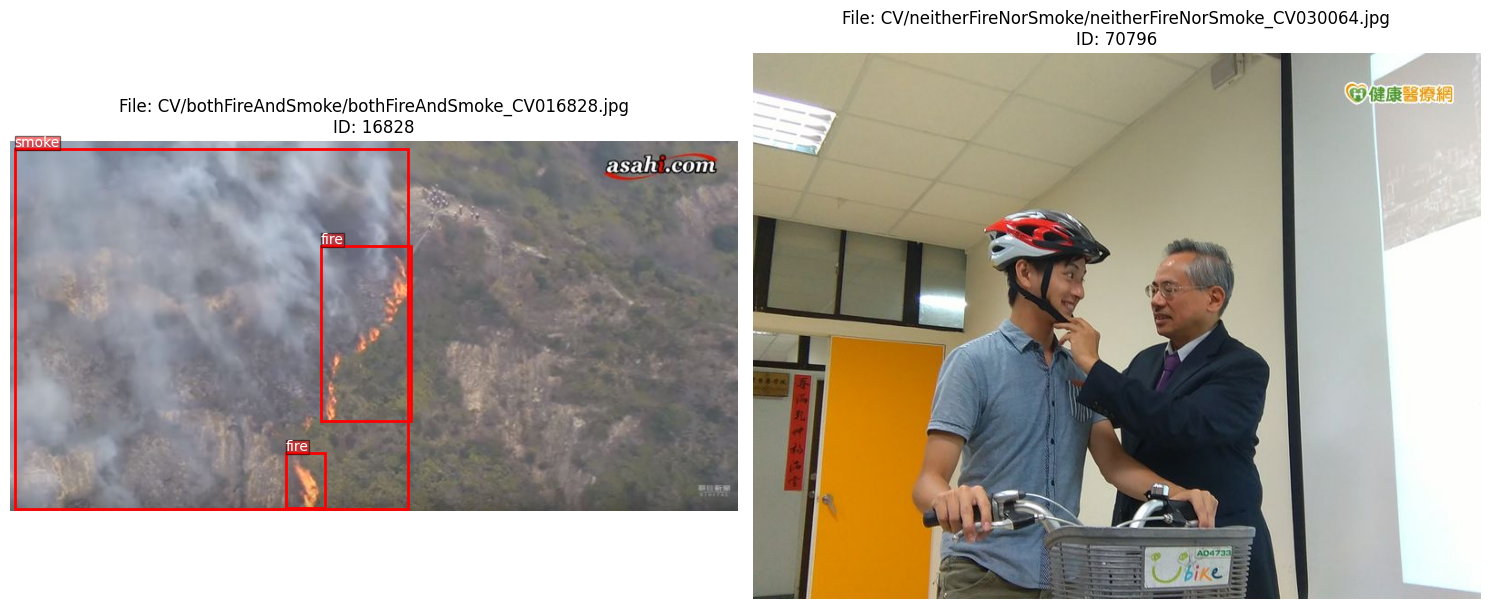

: 

In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import numpy as np
from pathlib import Path

def visualize_samples(ann_path, img_root, num_samples=2):
    # Load annotations
    with open(ann_path, 'r') as f:
        coco = json.load(f)
    
    # Map categories
    cats = {cat['id']: cat['name'] for cat in coco['categories']}
    
    # Get images with annotations
    img_ids = [img['id'] for img in coco['images']]
    
    # Filter images that actually exist
    valid_img_ids = []
    for img_id in img_ids:
        img_info = next(img for img in coco['images'] if img['id'] == img_id)
        if (img_root / img_info['file_name']).exists():
            valid_img_ids.append(img_id)
            
    if len(valid_img_ids) < num_samples:
        print(f"Not enough valid images found. Found {len(valid_img_ids)}")
        return

    # Sample images
    sample_ids = random.sample(valid_img_ids, num_samples)
    
    # Create plot
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 8))
    if num_samples == 1:
        axes = [axes]
        
    for ax, img_id in zip(axes, sample_ids):
        img_info = next(img for img in coco['images'] if img['id'] == img_id)
        img_path = img_root / img_info['file_name']
        
        # Load image
        img = Image.open(img_path)
        ax.imshow(img)
        
        # Get annotations for this image
        anns = [ann for ann in coco['annotations'] if ann['image_id'] == img_id]
        
        for ann in anns:
            bbox = ann['bbox']
            cat_name = cats.get(ann['category_id'], 'unknown')
            
            # Draw box
            rect = patches.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3],
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            
            # Draw label
            ax.text(
                bbox[0], bbox[1] - 2,
                cat_name,
                color='white',
                fontsize=10,
                bbox=dict(facecolor='red', alpha=0.5, pad=0)
            )
            
        ax.set_title(f"File: {img_info['file_name']}\nID: {img_id}")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run visualization
ann_file = Path('datasets_sample/annotations/COCO/Annotations/train.json')
img_dir = Path('datasets_sample/images')

if ann_file.exists() and img_dir.exists():
    visualize_samples(ann_file, img_dir)
else:
    print("Dataset paths not found.")